In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 

In [2]:
from sklearn.datasets import fetch_openml
import numpy as np
import matplotlib.pyplot as plt



(10000, 784)
(10000,)
True label for the plotted image is 5
              precision    recall  f1-score   support

           0       0.95      1.00      0.97       207
           1       0.97      0.98      0.97       216
           2       0.95      0.96      0.95       204
           3       0.92      0.92      0.92       192
           4       0.97      0.95      0.96       211
           5       0.98      0.92      0.95       176
           6       0.99      0.98      0.98       220
           7       0.96      0.97      0.97       216
           8       0.93      0.96      0.94       166
           9       0.95      0.92      0.94       192

    accuracy                           0.96      2000
   macro avg       0.96      0.96      0.96      2000
weighted avg       0.96      0.96      0.96      2000



['mnist_voting_clf.pkl']

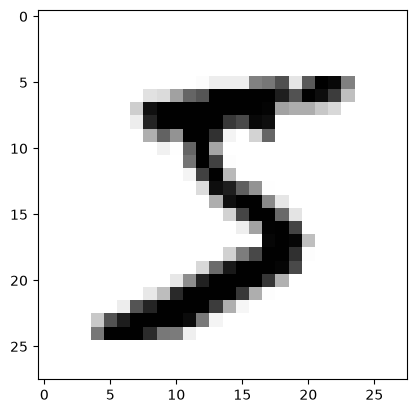

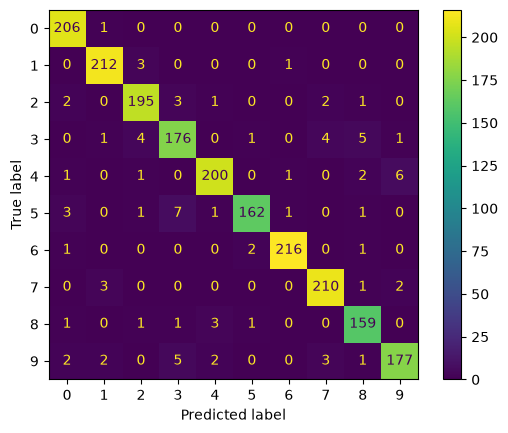

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from PIL import Image, ImageOps
import joblib

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, VotingClassifier

# Define a function that will be used later
def display_confusion_matrix(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    ConfusionMatrixDisplay(cm).plot()

# ---------- Load data and inspect it ----------
mnist = fetch_openml('mnist_784', version=1, cache=True, as_frame=False)
X = mnist["data"][:10000]
y = mnist["target"][:10000].astype(np.uint8)
print(X.shape)
print(y.shape)

some_digit = X[0]
some_digit_image = some_digit.reshape(28, 28)
plt.imshow(some_digit_image, cmap=mpl.cm.binary)
print("True label for the plotted image is", y[0])

# ---------- Train/test split ----------
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# ---------- Train an ensemble ----------
rf_clf = RandomForestClassifier(n_estimators=100, random_state=42)
et_clf = ExtraTreesClassifier(n_estimators=100, random_state=42)

voting_clf = VotingClassifier(
    estimators=[("rf", rf_clf), ("et", et_clf)],
    voting="soft"
)
voting_clf.fit(X_train, y_train)

y_pred = voting_clf.predict(X_test)
print(classification_report(y_test, y_pred))
display_confusion_matrix(y_test, y_pred)

# Save the trained model so predict_digit() below can reload it later
joblib.dump(voting_clf, "mnist_voting_clf.pkl")

In [3]:
# Define a function that will be used later
def display_confusion_matrix(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    ConfusionMatrixDisplay(cm).plot()

# ---------- Load data and inspect it ----------
mnist = fetch_openml('mnist_784', version=1, cache=True, as_frame=False)
X = mnist["data"][:10000]
y = mnist["target"][:10000].astype(np.uint8)
print(X.shape)
print(y.shape)


(10000, 784)
(10000,)


True label for the plotted image is 5


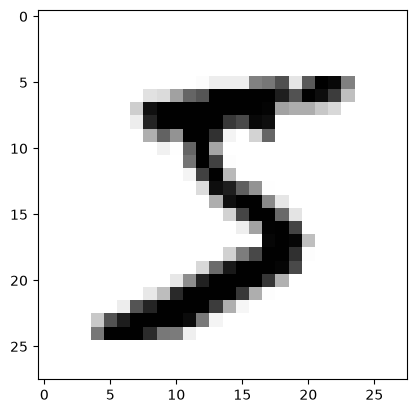

In [5]:
some_digit = X[0]
some_digit_image = some_digit.reshape(28, 28)
plt.imshow(some_digit_image, cmap=mpl.cm.binary)
print("True label for the plotted image is", y[0])